# Which early network signals of new topics travel? — RQ1 held-out demo

This notebook demonstrates the **held-out scoring stage** of the RQ1 experiment: *do early (t0..t0+2) network
indicators of a newly emerging scientific concept predict how the concept later spreads — beyond a simple
5-variable popularity baseline (B5) — and do the indicators chosen on the development domains **travel** to domains
that were sealed during selection?*

**The full pipeline** (orchestrated by the original `method.py`) has nine steps:
two zero-credit OpenAlex S3 passes over ~12.5k TAG-grounded concepts, ~53 indicators in 7 families
(popularity **E**, disciplinary **F**, landing **G**, retained-frontier **FR**, co-occurrence ego-network **A/D**,
co-author **S**), eight outcomes (uptake O1c/O1b, breadth O2r_m50/O2r_resid, transience O3, citation growth O4,
external recognition O5/O5_WW), a **DEV-only** ranking on CS/Eng/BGM/Med that froze a top-10 per outcome plus learned
models (ElasticNet / EBM), a hash seal, and a single unseal in which the frozen spec is scored on four held-out
domain groups (PHYS, LIFEENV, SOC, MATHDEC) and the 2010-14 cohort.

The S3 passes need many CPU-hours and hundreds of MB of snapshot data, so this demo starts from the artifact's
per-concept output (`method_out.json`): **100 held-out concepts (25 per held-out group, drawn among the 1,833
held-out concepts whose breadth outcome O2r_m50 is defined)** with their indicators, outcomes and the frozen models'
predictions. On that subset it re-runs, with the original code:

1. `heldout.py::job` — partial Spearman of each frozen indicator with the outcome **given B5** (+ onset-year dummies),
   with a concept bootstrap, in every held-out group;
2. `heldout.py::stage_score` — DerSimonian–Laird pooling over the four groups, sign agreement and Holm correction;
3. `heldout.py::stage_learned` — B5 vs B5 + best single indicator vs ElasticNet vs EBM (Spearman with the outcome,
   paired bootstrap against B5).

The final cells compare the demo numbers with the full-run numbers (n = 3,372 held-out concepts). With only 25
concepts per group the demo estimates are much noisier; the full-run result is that **breadth (O2r_m50 / O2r_resid)
is predictable beyond B5 and portable**, while uptake, citation growth and recognition are mostly not.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# --- original method.py imports ---
from __future__ import annotations

import argparse
import subprocess
import sys
import time
from pathlib import Path

# --- imports used by the held-out scoring code (heldout.py / lib/rq1stats.py) ---
import json
import math
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata, spearmanr

# --- notebook-only: visualisation ---
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-3/experiment-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["method_name"])
print(data["metadata"]["demo_subset"])
print("examples:", len(data["datasets"][0]["examples"]))

RQ1 held-out indicator portability (DEV freeze -> sealed held-out scoring)
25 concepts per held-out group (PHYS, LIFEENV, SOC, MATHDEC), stratified random sample (seed 20260928) of the 1,833 held-out concepts with a defined breadth outcome (O2r_m50) among the 3,372 held-out concepts in full_method_out.json
examples: 100


## Configuration

All tunable parameters of the scored stages. The original values are noted next to each one.
`MIN_N_LEARNED` is lowered because each demo group holds only 25 concepts (the original rule, n ≥ 30, would drop
every single group and leave only the pooled row).

In [5]:
SEED = 20260928          # original lib/common.py SEED
B_HELD = 1000            # concept-bootstrap resamples per (indicator, outcome, unit) psp   (original: 1000)
B_LEARNED = 500          # paired bootstrap resamples, learned model vs B5                 (original: 500)
MIN_N_LEARNED = 20       # min concepts per unit to score learned models                   (original: 30)
WORKERS = 5              # only used by the (dry-run) orchestrator below                    (original: 5)

# Outcomes scored in this demo: the continuous ones. The binary outcomes (O1b, O3, O5, O5_WW) are scored in
# heldout.py with logistic models refitted on the DEV rows, which are not part of the demo data.
DEMO_OUTCOMES = ["O1c", "O2r_m50", "O2r_resid", "O4"]

## 1. The pipeline orchestrator (`method.py`)

`method.py` is an idempotent orchestrator: it runs each step as a subprocess and skips a step whose output marker
already exists. It is reproduced here unchanged except that (i) `ROOT` is the notebook's working directory,
(ii) `lib/common.py`'s paths and logger are inlined, and (iii) a `--dry-run` flag prints the commands instead of
running them — the step scripts and the ~350 MB of S3 snapshot data are not part of this demo.

In [6]:
ROOT = Path.cwd()
# lib/common.py: DATA, LOGS, RES directories and setup_logger (inlined; the loguru logger is replaced by print)
DATA, LOGS, RES = ROOT / "data", ROOT / "logs", ROOT / "results"


class _PrintLogger:
    def info(self, msg):
        print(f"[method] {msg}")


def setup_logger(name):
    return _PrintLogger()


PY = sys.executable
STEPS = [
    ("tests", [["tests/test_units.py"], ["tests/t0_8_ego_port.py"]], RES / "t0_8_ego_port.json"),
    ("passA", [["passA.py", "--workers", "{w}"], ["passA.py", "--merge"]], DATA / "passA_info.json"),
    ("passB", [["passB.py", "--workers", "{w}"], ["passB.py", "--merge"]], DATA / "passB_info.json"),
    ("features", [["build_features.py", "--stage", "all", "--workers", "{w}"]], RES / "indicator_matrix.parquet"),
    ("outcomes", [["outcomes.py"]], DATA / "outcomes_sealed.parquet"),
    ("dev_select", [["dev_select.py", "--stage", "all", "--workers", "{w}"]], LOGS / "seal.log"),
    ("heldout", [["heldout.py", "--stage", "all", "--workers", "{w}"]], RES / "sensitivities_pooled.json"),
    ("audit", [["audit.py"]], RES / "audit.json"),
    ("outputs", [["make_outputs.py"]], RES / "rq1_heldout.json"),
]


def main(argv=None) -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--from", dest="start", default=None)
    ap.add_argument("--only", default=None)
    ap.add_argument("--workers", type=int, default=5)
    ap.add_argument("--dry-run", action="store_true")  # notebook addition: print commands only
    a = ap.parse_args(argv)
    logger = setup_logger("method")
    names = [s[0] for s in STEPS]
    i0 = names.index(a.start) if a.start else 0
    for name, cmds, marker in STEPS[i0:]:
        if a.only and name != a.only:
            continue
        if marker.exists() and not (a.only or a.start == name):
            logger.info(f"skip {name}: {marker.relative_to(ROOT)} exists")
            continue
        for c in cmds:
            cmd = [PY] + [x.format(w=a.workers) for x in c]
            t = time.time()
            logger.info(f"run {' '.join(c)}")
            if a.dry_run:
                continue
            r = subprocess.run(cmd, cwd=ROOT)
            if r.returncode != 0:
                raise SystemExit(f"step {name} failed ({' '.join(c)}), exit {r.returncode}")
            logger.info(f"done {' '.join(c)} in {(time.time()-t)/60:.1f} min")


main(["--dry-run", "--workers", str(WORKERS)])

[method] run tests/test_units.py
[method] run tests/t0_8_ego_port.py
[method] run passA.py --workers {w}
[method] run passA.py --merge
[method] run passB.py --workers {w}
[method] run passB.py --merge
[method] run build_features.py --stage all --workers {w}
[method] run outcomes.py
[method] run dev_select.py --stage all --workers {w}
[method] run heldout.py --stage all --workers {w}
[method] run audit.py
[method] run make_outputs.py


## 2. Statistics library (`lib/rq1stats.py`, verbatim)

* `psp_point` — **partial Spearman given a baseline**: rank x and y, residualise both on the ranks of the B5 baseline
  (+ category dummies, here onset-year dummies), then take the Pearson correlation of the residuals.
* `psp_boot` — the same with a concept bootstrap (ranks and residualisation are recomputed in every resample); it
  returns a Fisher-z estimate with a bootstrap SE for pooling. Units with fewer than 20 complete rows return NaN.
* `dersimonian_laird` — random-effects pooling over the held-out groups; `holm` — Holm step-down adjustment.

In [7]:
# lib/common.py / lib/indicators.py constants
HELD_GROUPS = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
CONT_OUTCOMES = ["O1c", "O2r_m50", "O2r_resid", "O4"]
BIN_OUTCOMES = ["O1b", "O3", "O5", "O5_WW"]
OUTCOMES = CONT_OUTCOMES + BIN_OUTCOMES


# ----------------------------------------------------------------------------- partial Spearman
def dummies(v: np.ndarray, drop_first: bool = True) -> np.ndarray:
    u = np.unique(v)
    if len(u) <= 1:
        return np.zeros((len(v), 0))
    cols = u[1:] if drop_first else u
    return (v[:, None] == cols[None, :]).astype(float)


def _resid(Z: np.ndarray, Y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def psp_point(x: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> float:
    """Pearson(resid(rank x ~ rank B + cat dummies), resid(rank y ~ same)). Rows must be complete."""
    Zc = [np.ones((len(x), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    R = _resid(Z, np.c_[rankdata(x), rankdata(y)])
    sx, sy = R[:, 0].std(), R[:, 1].std()
    if sx <= 1e-12 or sy <= 1e-12:
        return float("nan")
    return float(np.corrcoef(R[:, 0], R[:, 1])[0, 1])


def psp_boot(x, y, B, cat, n_boot: int, seed: int) -> dict:
    """Point + concept bootstrap (resample rows; ranks and residualisation recomputed in each resample)."""
    ok = np.isfinite(x) & np.isfinite(y)
    if B is not None:
        ok &= np.all(np.isfinite(B), axis=1)
    x, y = x[ok], y[ok]
    Bs = B[ok] if B is not None else None
    cs = cat[ok] if cat is not None else None
    n = len(x)
    if n < 20 or np.unique(x).size < 3:
        return {"n": int(n), "rho": float("nan"), "ci": [float("nan")] * 2, "se": float("nan"), "p": float("nan"),
                "boot": np.array([])}
    est = psp_point(x, y, Bs, cs)
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        bs[b] = psp_point(x[i], y[i], Bs[i] if Bs is not None else None, cs[i] if cs is not None else None)
    bs = bs[np.isfinite(bs)]
    lo, hi = np.percentile(bs, [2.5, 97.5]) if len(bs) else (np.nan, np.nan)
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1)) if len(z) > 2 else float("nan")
    ze = math.atanh(max(min(est, 0.999999), -0.999999)) if np.isfinite(est) else float("nan")
    p = float(2 * stats.norm.sf(abs(ze / se_z))) if se_z and np.isfinite(se_z) and se_z > 0 else float("nan")
    return {"n": int(n), "rho": est, "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "z": ze, "se_z": se_z, "p": p, "boot": bs}


def spearman_raw(x, y) -> tuple[float, int]:
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 10 or np.unique(x[ok]).size < 3:
        return float("nan"), int(ok.sum())
    return float(stats.spearmanr(x[ok], y[ok])[0]), int(ok.sum())


# ----------------------------------------------------------------------------- pooling / multiplicity
def dersimonian_laird(b, se) -> dict:
    """EXP6 lib/stats_core.dersimonian_laird (verbatim logic)."""
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0, "b": float("nan"), "se": float("nan"), "ci": [float("nan")] * 2, "p": float("nan"),
                "tau2": float("nan"), "I2": float("nan"), "Q": float("nan")}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 and Cc > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


def holm(p: list[float]) -> list[float]:
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = np.isfinite(p)
    idx = np.nonzero(ok)[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * p[i]))
        out[i] = run
    return out.tolist()


def sign_test_two_sided(k_pos: int, n: int) -> float:
    return float(stats.binomtest(k_pos, n, 0.5).pvalue) if n > 0 else float("nan")

## 3. The analysis table (replaces `heldout.py::stage_unseal`)

In the full pipeline, `stage_unseal` opens the hash-sealed held-out outcomes once and joins them to the indicator
matrix (`data/analysis_table.parquet`). Here the same table is rebuilt from the demo examples: one row per concept
with its onset year `t0`, held-out `unit`, the ~53 indicators + B5 (measured over t0..t0+2), the 8 outcomes, and
the frozen models' predictions. The frozen DEV spec (top-10 per outcome, union top-10, frozen signs) ships in the
data file's metadata.

In [8]:
spec = data["metadata"]["frozen_spec"]
rows = []
for e in data["datasets"][0]["examples"]:
    inp, out = json.loads(e["input"]), json.loads(e["output"])
    r = {"ci": e["metadata_ci"], "concept": inp["concept"], "concept_id": inp["concept_id"], "t0": inp["t0"],
         "group": inp["home_group"], "unit": e["metadata_unit"], "split": e["metadata_split"]}
    r.update(inp["indicators_t0_t0p2"])
    r.update(out)
    r.update({k: float(v) for k, v in e.items() if k.startswith("predict_") and v not in (None, "")})
    rows.append(r)
A = pd.DataFrame(rows)
for c in A.columns:
    if c not in ("concept", "concept_id", "group", "unit", "split"):
        A[c] = pd.to_numeric(A[c], errors="coerce")
G = {"A": A, "spec": spec}   # what heldout.py::_init loads in every worker process
print(A.shape)
print(A.groupby("unit").size().to_string())
A[["concept", "unit", "t0"] + B5 + DEMO_OUTCOMES].head(8)

(100, 105)
unit
LIFEENV    25
MATHDEC    25
PHYS       25
SOC        25


,concept,unit,t0,logvol,growth_c,offhome_share,entropy,reach,O1c,O2r_m50,O2r_resid,O4
0,Helicene,PHYS,2009,3.970292,-0.405465,0.100000,0.458301,2.0,1.079564,5.753697,1.437920,0.049795
1,AERONET,PHYS,2003,4.060443,-0.233615,0.317073,1.108087,5.0,0.534677,4.421568,0.070034,0.038949
2,Second law of thermodynamics,PHYS,2007,4.110874,0.044452,0.291667,1.060703,3.0,0.108634,7.941176,3.569641,0.178094
3,Potassium carbonate,PHYS,2008,4.060443,-0.451985,0.536585,1.152892,4.0,0.461346,4.656017,0.304483,0.372188
4,Vanadium dioxide,PHYS,2009,4.394449,0.342945,0.122807,0.974174,3.0,0.711496,5.106773,0.622762,-0.158869
5,Shikimic acid,PHYS,2007,4.430817,0.068993,0.666667,1.570458,5.0,0.296571,8.055699,3.557264,0.151427
6,Multiplicative noise,PHYS,2004,4.248495,0.000000,0.518519,1.598558,7.0,0.587787,7.359472,2.933351,0.151323
7,Induced polarization,PHYS,2006,4.143135,0.040822,0.103448,1.091588,4.0,0.481838,7.875328,3.490996,0.240496


## 4. Scoring one frozen indicator in one unit (`heldout.py::job`, continuous branch)

For each `(indicator, outcome, unit)`: the partial Spearman given B5 + onset-year dummies with `B_HELD` concept
bootstrap resamples, plus the raw Spearman with a percentile-bootstrap CI (used by pre-registered predictions P1/P2).
The binary branch (frozen DEV logistic coefficients + joint refit bootstrap) needs the DEV rows and is omitted.

In [9]:
def cat_for(d: pd.DataFrame, unit: str) -> np.ndarray:
    parts = [dummies(d.t0.to_numpy())]
    if unit in ("COH_DEVHOME", "COH_OTHER", "ALL_DEV"):
        parts.append(dummies(d.group.to_numpy()))
    return np.hstack(parts)


def job(args):
    """kind: cont | port. Returns a dict row. (The 'bin' kind of the original is not available in the demo.)"""
    kind, ind, outcome, unit, nboot, seed, extra = args
    A = G["A"]
    spec = G["spec"]
    d = A[A.unit == unit] if unit != "ALL_DEV" else A[A.split == "DEV"]
    y = d[outcome].to_numpy(float)
    x = d[ind].to_numpy(float)
    row = {"indicator": ind, "outcome": outcome, "unit": unit, "kind": kind}
    if kind in ("cont", "port"):
        cov = B5 + (extra.get("covs", []) if extra else [])
        if extra and extra.get("drop_reach"):
            cov = [c for c in cov if c != "reach"]
        r = psp_boot(x, y, d[cov].to_numpy(float), cat_for(d, unit), nboot, seed)
        raw, nraw = spearman_raw(x, y)
        row.update(n=r["n"], rho=r["rho"], ci_lo=r["ci"][0], ci_hi=r["ci"][1], se=r["se"], z=r.get("z"),
                   se_z=r.get("se_z"), p=r["p"], raw_rho=raw)
        # raw Spearman CI (percentile bootstrap) for P1/P2
        if kind == "cont" or (kind == "port" and outcome == "O2r_m50"):
            ok = np.isfinite(x) & np.isfinite(y)
            xs, ys = x[ok], y[ok]
            rng = np.random.default_rng(seed + 1)
            bs = []
            if ok.sum() >= 20:
                for _ in range(min(nboot, 500)):
                    i = rng.integers(0, len(xs), len(xs))
                    bs.append(np.corrcoef(rankdata(xs[i]), rankdata(ys[i]))[0, 1])
            row.update(raw_ci_lo=float(np.nanpercentile(bs, 2.5)) if bs else np.nan,
                       raw_ci_hi=float(np.nanpercentile(bs, 97.5)) if bs else np.nan)
        return row
    raise ValueError(f"kind {kind!r} needs the DEV rows, not in the demo data")


# a single call: the top frozen breadth indicator in PHYS
pd.Series(job(("cont", "M0_density_end", "O2r_m50", "PHYS", B_HELD, SEED, None)))

indicator    M0_density_end
outcome             O2r_m50
unit                   PHYS
kind                   cont
n                        25
rho                0.316801
ci_lo              -0.85752
ci_hi              0.979393
se                 0.480312
z                  0.328088
se_z               1.373437
p                  0.811198
raw_rho            0.635385
raw_ci_lo          0.248131
raw_ci_hi          0.861989
dtype: object

## 5. Frozen scoring, pooling, sign agreement and Holm (`heldout.py::stage_score`)

Every frozen top-10 indicator (plus the union top-10) is scored in every held-out group. For each indicator the
four per-group Fisher-z estimates are pooled with DerSimonian–Laird; an indicator is **confirmed** if its Holm-adjusted
pooled p < 0.05 *and* the pooled sign matches the sign frozen on DEV. The original runs the jobs in a
`ProcessPoolExecutor`; here they run sequentially, and the demo has only the four held-out groups (the full run also
reports the two cohort units in the sign-agreement count).

In [10]:
UNITS = HELD_GROUPS   # original: HELD_GROUPS + ["COH_DEVHOME", "COH_OTHER"]; the cohort rows are not in the demo


def pool_block(tab: pd.DataFrame, value: str, se: str) -> dict:
    t = tab[tab.unit.isin(HELD_GROUPS)]
    return dersimonian_laird(t[value].to_numpy(float), t[se].to_numpy(float))


top = spec["top10"]
union = spec["union_top10"]
jobs = []
for o in DEMO_OUTCOMES:
    if o not in top:
        continue
    inds = list(dict.fromkeys([d["indicator"] for d in top[o]] + union))
    kind = "cont" if o in CONT_OUTCOMES else "bin"
    for i, ind in enumerate(inds):
        for u in UNITS:
            jobs.append((kind, ind, o, u, B_HELD, SEED + 31 * i, None))
t = time.time()
warnings.filterwarnings("ignore")
tab = pd.DataFrame([job(j) for j in jobs])
print(f"held-out frozen scoring: {len(jobs)} jobs in {time.time()-t:.1f} s")

# --------------- pooling, signs, Holm
summary = {}
for o in DEMO_OUTCOMES:
    is_c = o in CONT_OUTCOMES
    members = [d["indicator"] for d in top[o]]
    inds = list(dict.fromkeys(members + union))
    rows = []
    for ind in inds:
        tt = tab[(tab.outcome == o) & (tab.indicator == ind)]
        sgn = spec["signs"][o].get(ind, 1)
        pl = pool_block(tt, "z", "se_z")
        est = float(np.tanh(pl["b"])) if pl["k"] else np.nan
        ci = [float(np.tanh(pl["ci"][0])), float(np.tanh(pl["ci"][1]))] if pl["k"] else [np.nan] * 2
        vals = tt.set_index("unit").rho
        signs = [int(np.sign(v)) == sgn for v in vals.reindex(UNITS).to_numpy() if np.isfinite(v)]
        k_agree = int(sum(signs))
        rows.append({"indicator": ind, "in_top10": ind in members, "in_union": ind in union, "frozen_sign": sgn,
                     "pooled": est, "pooled_ci": ci, "pooled_p": pl.get("p"), "tau2": pl.get("tau2"),
                     "I2": pl.get("I2"), "k": pl.get("k"), "sign_agree": k_agree, "n_units": len(signs),
                     "sign_test_p": sign_test_two_sided(k_agree, len(signs)),
                     "per_unit": {u: (None if not np.isfinite(v) else float(v))
                                  for u, v in vals.reindex(UNITS).items()},
                     "per_unit_n": {r.unit: int(r.n) for r in tt.itertuples()}})
    hp = holm([r["pooled_p"] for r in rows if r["in_top10"]])
    k = 0
    for r in rows:
        if r["in_top10"]:
            r["holm_p"] = hp[k]; k += 1
            r["confirmed"] = bool(np.isfinite(r["holm_p"]) and r["holm_p"] < 0.05
                                  and np.sign(r["pooled"]) == r["frozen_sign"])
    summary[o] = rows

for o in DEMO_OUTCOMES:
    conf = [r["indicator"] for r in summary[o] if r.get("confirmed")]
    print(f"{o:10s} confirmed {len(conf)}/10 frozen top-10: {conf}")

held-out frozen scoring: 268 jobs in 83.5 s
O1c        confirmed 0/10 frozen top-10: []
O2r_m50    confirmed 0/10 frozen top-10: []
O2r_resid  confirmed 0/10 frozen top-10: []
O4         confirmed 0/10 frozen top-10: []


## 6. Learned models vs single indicator vs B5 (`heldout.py::stage_learned`, continuous outcomes)

The frozen DEV models are: **B5** (OLS on the baseline), **B5 + best single** (B5 plus the DEV #1 indicator),
**linear_all** (ElasticNet on all indicators) and **EBM** (explainable boosting machine). The original loads the
joblib models and predicts; here their held-out predictions are taken from the artifact's output
(`predict_*` fields — identical numbers, since the models were frozen before the unseal). The metric is the
Spearman correlation of prediction and outcome, with a paired concept bootstrap of the difference against B5.

In [11]:
PRED_KEYS = {"B5": "predict_B5", "B5_best_single": "predict_best_single", "linear_all": "predict_linear_all",
             "EBM": "predict_EBM"}
rng = np.random.default_rng(SEED)
res = {}
d = A[A.split != "DEV"].copy()
for o in DEMO_OUTCOMES:
    is_bin = o in BIN_OUTCOMES
    P = {k: d[f"{v}_{o}"].to_numpy(float) for k, v in PRED_KEYS.items() if f"{v}_{o}" in d}
    y = d[o].to_numpy(float)
    res[o] = {}
    for u in UNITS + ["POOLED_HELDOUT"]:
        mk = (d.unit.isin(HELD_GROUPS) if u == "POOLED_HELDOUT" else (d.unit == u)).to_numpy() & np.isfinite(y)
        if mk.sum() < MIN_N_LEARNED:
            res[o][u] = {"n": int(mk.sum()), "status": "dropped"}
            continue
        yy = y[mk]

        def metric(p, yv):
            return float(spearmanr(p, yv)[0])
        r = {"n": int(mk.sum())}
        for k, p in P.items():
            pp = p[mk]
            r[k] = {"metric": metric(pp, yy)}
            r[k]["r2"] = float(1 - np.sum((yy - pp) ** 2) / np.sum((yy - yy.mean()) ** 2))
        bs = {k: [] for k in P if k != "B5"}
        for _ in range(B_LEARNED):
            j = rng.integers(0, len(yy), len(yy))
            b0 = metric(P["B5"][mk][j], yy[j])
            for k in bs:
                bs[k].append(metric(P[k][mk][j], yy[j]) - b0)
        for k, v in bs.items():
            v = np.array(v)
            r[k]["delta_vs_B5"] = r[k]["metric"] - r["B5"]["metric"]
            r[k]["delta_ci"] = [float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5))]
        res[o][u] = r

for o in DEMO_OUTCOMES:
    r = res[o]["POOLED_HELDOUT"]
    print(f"{o:10s} n={r['n']:3d}  " + "  ".join(f"{k}={r[k]['metric']:+.3f}" for k in PRED_KEYS))

O1c        n=100  B5=+0.197  B5_best_single=+0.202  linear_all=+0.164  EBM=+0.200
O2r_m50    n=100  B5=+0.768  B5_best_single=+0.823  linear_all=+0.837  EBM=+0.813
O2r_resid  n=100  B5=+0.779  B5_best_single=+0.829  linear_all=+0.837  EBM=+0.818
O4         n=100  B5=+0.032  B5_best_single=+0.129  linear_all=+nan  EBM=+0.381


## 7. Results: demo subset vs full run

The tables put the demo's pooled partial Spearman (100 concepts) next to the full-run value (all held-out concepts
with a defined outcome: 1,833 for breadth, 3,372 for O1c/O4) for each frozen top-10 indicator, and the
learned-model comparison next to its full-run counterpart.

With 25 concepts per group and 12 nuisance columns (intercept, 5 B5 ranks, 6 onset-year dummies) absorbed before
correlating, many bootstrap resamples give residual correlations near ±1, which inflates the Fisher-z SE; the demo's
pooled CIs therefore span most of [-1, 1] and nothing is "confirmed" at this size. What *does* carry over is the
**direction and rough magnitude**: compare the `demo_psp` and `full_psp` columns, the per-group sign agreement,
and the learned-model gains over B5 for breadth.

In [12]:
ref = data["metadata"]["full_run_reference"]
pd.set_option("display.width", 200)
for o in ("O2r_m50", "O2r_resid", "O1c", "O4"):
    full = {r["indicator"]: r for r in ref["heldout_summary"][o]}
    tb = pd.DataFrame([{
        "indicator": r["indicator"], "frozen_sign": r["frozen_sign"],
        "demo_psp": r["pooled"], "demo_ci": f"[{r['pooled_ci'][0]:+.2f}, {r['pooled_ci'][1]:+.2f}]",
        "demo_sign_agree": f"{r['sign_agree']}/{r['n_units']}", "demo_confirmed": r.get("confirmed"),
        "full_psp": full[r["indicator"]]["pooled"],
        "full_ci": f"[{full[r['indicator']]['pooled_ci'][0]:+.2f}, {full[r['indicator']]['pooled_ci'][1]:+.2f}]",
        "full_confirmed": full[r["indicator"]].get("confirmed")} for r in summary[o] if r["in_top10"]])
    same = int((np.sign(tb.demo_psp) == np.sign(tb.full_psp)).sum())
    print(f"\n=== {o}: frozen top-10, pooled psp | B5 over PHYS/LIFEENV/SOC/MATHDEC "
          f"(demo sign = full-run sign for {same}/10) ===")
    print(tb.round(3).to_string(index=False))

print("\n=== learned vs single vs B5, pooled held-out Spearman (demo n=100 | full run) ===")
lv = []
for o in DEMO_OUTCOMES:
    for k in PRED_KEYS:
        fr = (ref["learned_vs_single_pooled_heldout"].get(o) or {}).get(k, {})
        lv.append({"outcome": o, "model": k, "demo": res[o]["POOLED_HELDOUT"][k]["metric"],
                   "demo_delta_vs_B5": res[o]["POOLED_HELDOUT"][k].get("delta_vs_B5"),
                   "full": fr.get("metric"), "full_delta_vs_B5": fr.get("delta_vs_B5")})
lv = pd.DataFrame(lv)
print(lv.round(3).to_string(index=False))


=== O2r_m50: frozen top-10, pooled psp | B5 over PHYS/LIFEENV/SOC/MATHDEC (demo sign = full-run sign for 10/10) ===
            indicator  frozen_sign  demo_psp        demo_ci demo_sign_agree  demo_confirmed  full_psp        full_ci  full_confirmed
       M0_density_end            1     0.352 [-0.74, +0.93]             4/4           False     0.375 [+0.28, +0.46]            True
            D_vol_end            1     0.396 [-0.63, +0.92]             4/4           False     0.307 [+0.26, +0.36]            True
        CONTACT_REACH            1     0.411 [-0.67, +0.93]             4/4           False     0.211 [+0.16, +0.26]            True
            n_comm_W3            1     0.361 [-0.71, +0.93]             4/4           False     0.167 [+0.06, +0.27]            True
                   RS           -1    -0.227 [-0.91, +0.79]             3/4           False    -0.072 [-0.15, +0.01]           False
                G_btw            1     0.139 [-0.74, +0.84]             3/4          

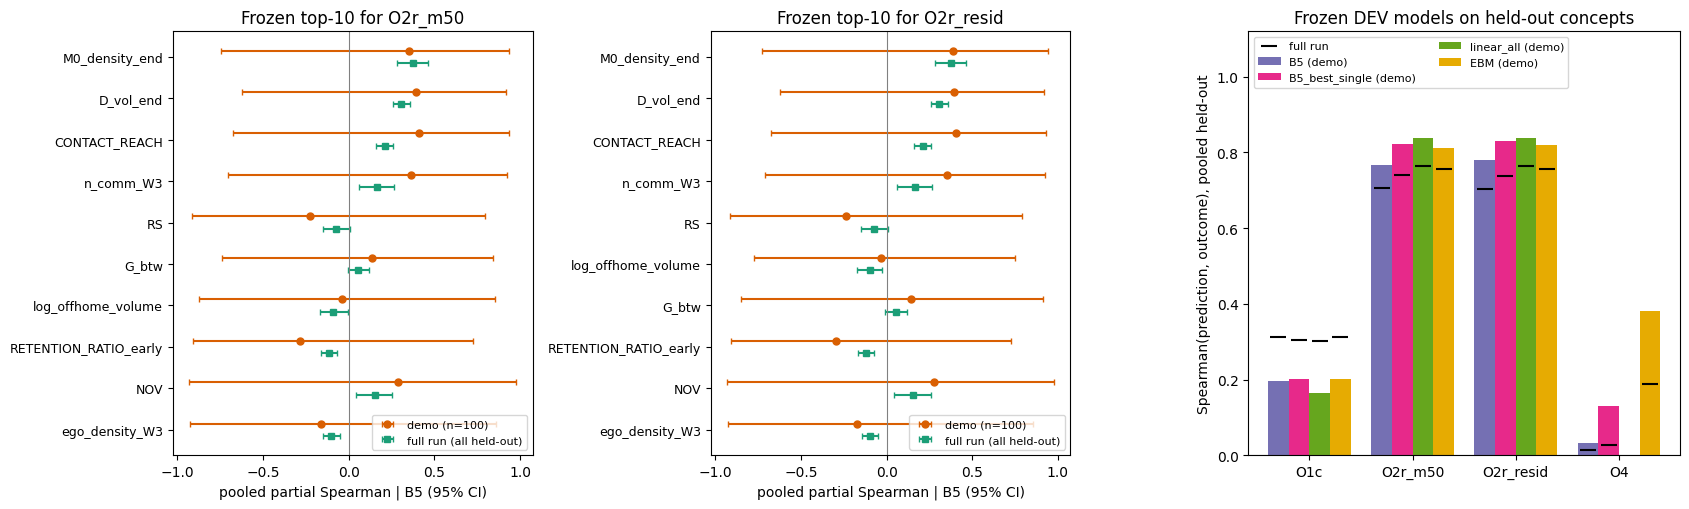

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), gridspec_kw={"width_ratios": [1, 1, 1.2]})
# (a, b) forest plots: pooled psp | B5 for the frozen breadth indicators, demo vs full run
for ax, o in zip(axes[:2], ("O2r_m50", "O2r_resid")):
    full = {r["indicator"]: r for r in ref["heldout_summary"][o]}
    rs = [r for r in summary[o] if r["in_top10"]]
    ypos = np.arange(len(rs))[::-1]
    for yv, r in zip(ypos, rs):
        f = full[r["indicator"]]
        ax.errorbar(r["pooled"], yv + 0.15, xerr=[[r["pooled"] - r["pooled_ci"][0]], [r["pooled_ci"][1] - r["pooled"]]],
                    fmt="o", color="#d95f02", ms=5, capsize=2, label="demo (n=100)" if yv == ypos[0] else None)
        ax.errorbar(f["pooled"], yv - 0.15, xerr=[[f["pooled"] - f["pooled_ci"][0]], [f["pooled_ci"][1] - f["pooled"]]],
                    fmt="s", color="#1b9e77", ms=5, capsize=2, label="full run (all held-out)" if yv == ypos[0] else None)
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["indicator"] for r in rs], fontsize=9)
    ax.set_xlabel("pooled partial Spearman | B5 (95% CI)")
    ax.set_title(f"Frozen top-10 for {o}")
    ax.legend(fontsize=8, loc="lower right")
# (c) learned vs single vs B5
ax = axes[2]
w = 0.2
xs = np.arange(len(DEMO_OUTCOMES))
cols = {"B5": "#7570b3", "B5_best_single": "#e7298a", "linear_all": "#66a61e", "EBM": "#e6ab02"}
for i, k in enumerate(PRED_KEYS):
    sub = lv[lv.model == k].set_index("outcome").reindex(DEMO_OUTCOMES)
    ax.bar(xs + (i - 1.5) * w, sub.demo, w, color=cols[k], label=f"{k} (demo)")
    ax.scatter(xs + (i - 1.5) * w, sub.full, color="k", marker="_", s=120, zorder=3,
               label="full run" if i == 0 else None)
ax.set_xticks(xs)
ax.set_xticklabels(DEMO_OUTCOMES)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylim(top=1.12)   # room for the legend above the bars
ax.set_ylabel("Spearman(prediction, outcome), pooled held-out")
ax.set_title("Frozen DEV models on held-out concepts")
ax.legend(fontsize=8, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()